In [3]:
import pandas as pd

df = pd.read_csv("../feature-engineering/output/dataset_churn.csv")

print("Linhas:", len(df))
print("Colunas:", len(df.columns))

df.head()

Linhas: 500
Colunas: 12


,cliente_id,total_atendimentos,total_gasto,ticket_medio,dias_desde_ultimo_atendimento,intervalo_medio_atendimentos,atendimentos_30d,atendimentos_90d,gasto_90d,quantidade_servicos_diferentes,quantidade_profissionais_diferentes,target_churn
0,mock-cli-00001,1,162.48,162.48,99,0.00,0,0,0.00,1,1,1.0
1,mock-cli-00002,7,1495.73,213.68,3,61.50,1,2,147.79,8,5,0.0
2,mock-cli-00003,0,0.00,0.00,-1,0.00,0,0,0.00,0,0,NaN
3,mock-cli-00004,0,0.00,0.00,-1,0.00,0,0,0.00,0,0,NaN
4,mock-cli-00005,7,1208.66,172.67,1,53.67,1,2,811.75,7,5,0.0


In [8]:
print(df["target_churn"].value_counts())

print("\nProporção:")
print(df["target_churn"].value_counts(normalize=True))

target_churn
0.0    326
1.0    121
Name: count, dtype: int64

Proporção:
target_churn
0.0    0.729306
1.0    0.270694
Name: proportion, dtype: float64


In [9]:
features_modelo_a = [
    "total_atendimentos",
    "total_gasto",
    "ticket_medio",
    "dias_desde_ultimo_atendimento",
    "intervalo_medio_atendimentos",
    "atendimentos_30d",
    "atendimentos_90d",
    "gasto_90d"
]

comparacao = df.groupby("target_churn")[features_modelo_a].mean().T

comparacao

target_churn,0.0,1.0
total_atendimentos,3.177914,2.958678
total_gasto,647.098681,514.039587
ticket_medio,138.518466,164.393884
dias_desde_ultimo_atendimento,33.481595,62.727273
intervalo_medio_atendimentos,32.786595,54.986033
atendimentos_30d,0.407975,0.413223
atendimentos_90d,1.141104,0.925620
gasto_90d,243.986595,150.428430


In [10]:
df[features_modelo_a].isnull().sum()

total_atendimentos               0
total_gasto                      0
ticket_medio                     0
dias_desde_ultimo_atendimento    0
intervalo_medio_atendimentos     0
atendimentos_30d                 0
atendimentos_90d                 0
gasto_90d                        0
dtype: int64

In [11]:
df[features_modelo_a].describe().T

,count,mean,std,min,25%,50%,75%,max
total_atendimentos,500.0,2.78800,2.945574,0.0,0.0,2.000,4.0000,14.00
total_gasto,500.0,546.30592,702.096239,0.0,0.0,271.015,806.0850,3886.82
ticket_medio,500.0,130.09736,120.422077,0.0,0.0,125.120,190.9725,813.75
dias_desde_ultimo_atendimento,500.0,36.90400,53.107472,-1.0,-1.0,18.000,49.0000,350.00
intervalo_medio_atendimentos,500.0,34.68348,39.309818,0.0,0.0,31.320,59.5000,244.00
atendimentos_30d,500.0,0.36600,0.494503,0.0,0.0,0.000,1.0000,2.00
atendimentos_90d,500.0,0.96800,1.008469,0.0,0.0,1.000,2.0000,4.00
gasto_90d,500.0,195.48294,287.521517,0.0,0.0,76.360,267.4775,1807.73


In [12]:
# existe vazamento de informações (Data leakage)
print(df[features_modelo_a + ["target_churn"]].corr()["target_churn"].sort_values())

gasto_90d                       -0.140758
atendimentos_90d                -0.095219
total_gasto                     -0.082729
total_atendimentos              -0.033111
atendimentos_30d                 0.004615
ticket_medio                     0.097363
dias_desde_ultimo_atendimento    0.238924
intervalo_medio_atendimentos     0.249294
target_churn                     1.000000
Name: target_churn, dtype: float64


In [13]:
#vizualizando e analisando clientes sem historico de atendimento

df_sem_target = df[
    df["target_churn"].isna()
].copy()

print("Clientes sem target:", len(df_sem_target))

Clientes sem target: 53


In [6]:
# Criar o dataset do modelo

features_modelos = [
    "total_atendimentos",
    "total_gasto",
    "ticket_medio",
    "dias_desde_ultimo_atendimento",
    "intervalo_medio_atendimentos",
    "atendimentos_30d",
    "atendimentos_90d",
    "gasto_90d"
]

df_modelo = df.dropna(
    subset=["target_churn"]
).copy()

df_modelo["target_churn"] = (
    df_modelo["target_churn"]
    .astype(int)
)

X = df_modelo[features_modelos]
y = df_modelo["target_churn"]

In [7]:
print("Registros:", len(df_modelo))
print("Features:", X.shape[1])

print("\nDistribuição:")
print(y.value_counts())

print("\nValores nulos:")
print(X.isnull().sum())

Registros: 447
Features: 8

Distribuição:
target_churn
0    326
1    121
Name: count, dtype: int64

Valores nulos:
total_atendimentos               0
total_gasto                      0
ticket_medio                     0
dias_desde_ultimo_atendimento    0
intervalo_medio_atendimentos     0
atendimentos_30d                 0
atendimentos_90d                 0
gasto_90d                        0
dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 357
Teste: 90


In [20]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

In [ ]:
# X_train_model → usado para treinar
# X_val         → usado para escolher o threshold
# X_test        → NÃO TOCAR

In [19]:
print("Treinamento:", X_train_model.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

print("\nTarget treinamento:")
print(y_train_model.value_counts())

print("\nTarget validação:")
print(y_val.value_counts())

print("\nTarget teste:")
print(y_test.value_counts())

Treinamento: (267, 8)
Validação: (90, 8)
Teste: (90, 8)

Target treinamento:
target_churn
0    194
1     73
Name: count, dtype: int64

Target validação:
target_churn
0    66
1    24
Name: count, dtype: int64

Target teste:
target_churn
0    66
1    24
Name: count, dtype: int64


In [10]:
# Treinar o modelo

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [11]:
y_pred = modelo_rf.predict(X_test)

In [12]:
y_prob = modelo_rf.predict_proba(X_test)[:, 1]

In [13]:
y_prob

array([0.33, 0.39, 0.  , 0.44, 0.26, 0.54, 0.44, 0.  , 0.91, 0.  , 0.  ,
       0.  , 0.17, 0.41, 0.  , 0.27, 0.  , 0.5 , 0.  , 0.  , 0.31, 0.  ,
       0.  , 0.  , 0.  , 0.31, 0.47, 0.  , 0.11, 0.02, 0.51, 0.52, 0.35,
       0.3 , 0.16, 0.26, 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.48,
       0.7 , 0.12, 0.  , 0.48, 0.26, 0.05, 0.45, 0.35, 0.55, 0.3 , 0.02,
       0.07, 0.03, 0.51, 0.  , 0.71, 0.  , 0.46, 0.48, 0.44, 0.31, 0.4 ,
       0.  , 0.1 , 0.29, 0.09, 0.41, 0.52, 0.1 , 0.06, 0.  , 0.47, 0.35,
       0.23, 0.47, 0.45, 0.6 , 0.27, 0.14, 0.13, 0.32, 0.29, 0.24, 0.19,
       0.04, 0.21])

In [14]:
# Avaliando o modelo

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7777777777777778
Precision: 0.7
Recall: 0.2916666666666667
F1: 0.4117647058823529
ROC-AUC: 0.8529040404040404

Matriz de Confusão:
[[63  3]
 [17  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        66
           1       0.70      0.29      0.41        24

    accuracy                           0.78        90
   macro avg       0.74      0.62      0.64        90
weighted avg       0.76      0.78      0.74        90



In [21]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf_val = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf_val.fit(X_train_model, y_train_model)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [22]:
y_val_prob = modelo_rf_val.predict_proba(X_val)[:, 1]

In [29]:
# Testar vários thresholds

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

resultados = []

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    resultados.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })



In [30]:
import pandas as pd

df_thresholds = pd.DataFrame(resultados)

df_thresholds

,threshold,precision,recall,f1
0,0.10,0.377049,0.958333,0.541176
1,0.15,0.407407,0.916667,0.564103
2,0.20,0.403846,0.875000,0.552632
3,0.25,0.422222,0.791667,0.550725
4,0.30,0.425000,0.708333,0.531250
5,0.35,0.388889,0.583333,0.466667
6,0.40,0.424242,0.583333,0.491228
7,0.45,0.428571,0.500000,0.461538
8,0.50,0.400000,0.416667,0.408163
9,0.55,0.391304,0.375000,0.382979


In [31]:
melhor_resultado = df_thresholds.loc[
    df_thresholds["f1"].idxmax()
]

melhor_threshold = melhor_resultado["threshold"]

print("Melhor threshold:", melhor_threshold)
print("Precision:", melhor_resultado["precision"])
print("Recall:", melhor_resultado["recall"])
print("F1:", melhor_resultado["f1"])

Melhor threshold: 0.15
Precision: 0.4074074074074074
Recall: 0.9166666666666666
F1: 0.5641025641025641


In [32]:
# Treinar o modelo final

from sklearn.ensemble import RandomForestClassifier

modelo_rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf_final.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [34]:
# Gerar probabilidades no X_test

y_test_prob = modelo_rf_final.predict_proba(X_test)[:, 1]

In [35]:
# Aplicar o threshold escolhido

THRESHOLD = 0.15

y_test_pred = (
    y_test_prob >= THRESHOLD
).astype(int)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Threshold:", THRESHOLD)
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Threshold: 0.15
Accuracy: 0.6666666666666666
Precision: 0.44
Recall: 0.9166666666666666
F1: 0.5945945945945946
ROC-AUC: 0.8529040404040404

Matriz de Confusão:
[[38 28]
 [ 2 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.58      0.72        66
           1       0.44      0.92      0.59        24

    accuracy                           0.67        90
   macro avg       0.69      0.75      0.66        90
weighted avg       0.81      0.67      0.68        90



In [37]:
# Feature Importance do modelo_rf_final, que é o modelo treinado com todo o X_train.

import pandas as pd

importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importance": modelo_rf_final.feature_importances_
})

importancias = importancias.sort_values(
    by="importance",
    ascending=False
)

importancias

,feature,importance
2,ticket_medio,0.209682
1,total_gasto,0.201696
3,dias_desde_ultimo_atendimento,0.172580
7,gasto_90d,0.142344
4,intervalo_medio_atendimentos,0.132810
0,total_atendimentos,0.077991
6,atendimentos_90d,0.044559
5,atendimentos_30d,0.018338


<Axes: title={'center': 'Feature Importance — Random Forest'}, xlabel='feature'>

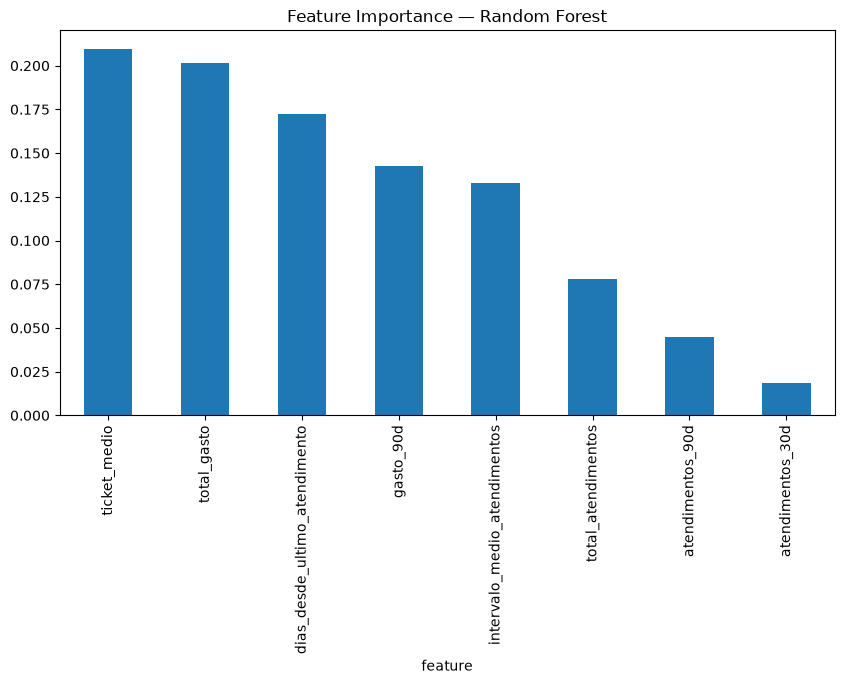

In [38]:
importancias.plot(
    x="feature",
    y="importance",
    kind="bar",
    legend=False,
    figsize=(10, 5),
    title="Feature Importance — Random Forest"
)

In [42]:
# Salvar o Modelo

import joblib

artefato_modelo = {
    "modelo": modelo_rf_final,
    "threshold": 0.15,
    "features": features_modelos
}

joblib.dump(
    artefato_modelo,
    "../output/random_forest_churn.pkl"
)

print("Modelo salvo com sucesso!!!")

Modelo salvo com sucesso!!!
